In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert to tensor (0-1 range)
    transforms.Normalize((0.5,), (0.5,))  # Normalize to (-1, 1)
])

In [ ]:
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 15.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 275kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.06MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.8MB/s]


In [ ]:
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [ ]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")

Training samples: 60000
Test samples: 10000
Batch size: 64


In [ ]:
model = nn.Sequential(
    nn.Flatten(),              # Flatten 28x28 images to 784 pixels
    nn.Linear(784, 512),       # First hidden layer
    nn.ReLU(),                 # ReLU activation
    nn.Linear(512, 256),       # Second hidden layer
    nn.ReLU(),                 # ReLU activation
    nn.Linear(256, 128),       # Third hidden layer
    nn.ReLU(),                 # ReLU activation
    nn.Linear(128, 10)         # Output layer (10 classes, no activation)
)

print("\nModel Architecture:")
print(model)


Model Architecture:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Linear(in_features=256, out_features=128, bias=True)
  (6): ReLU()
  (7): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")


Total parameters: 567,434


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"\nLoss function: Cross Entropy")
print(f"Optimizer: Adam")
print(f"Learning rate: {learning_rate}")


Loss function: Cross Entropy
Optimizer: Adam
Learning rate: 0.001


In [ ]:
num_epochs = 10
train_losses = []
train_accuracies = []

print(f"\nTraining for {num_epochs} epochs...\n")


Training for 10 epochs...



In [ ]:
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")


Epoch [1/10] - Loss: 0.5082, Accuracy: 81.28%
Epoch [2/10] - Loss: 0.3712, Accuracy: 86.24%
Epoch [3/10] - Loss: 0.3328, Accuracy: 87.63%
Epoch [4/10] - Loss: 0.3056, Accuracy: 88.69%
Epoch [5/10] - Loss: 0.2891, Accuracy: 89.25%
Epoch [6/10] - Loss: 0.2733, Accuracy: 89.99%
Epoch [7/10] - Loss: 0.2551, Accuracy: 90.46%
Epoch [8/10] - Loss: 0.2430, Accuracy: 90.97%
Epoch [9/10] - Loss: 0.2320, Accuracy: 91.31%
Epoch [10/10] - Loss: 0.2204, Accuracy: 91.71%


In [ ]:
model.eval()  # Set model to evaluation mode
correct = 0
total = 0

with torch.no_grad():  # Disable gradient computation
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"\nTest Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 87.77%


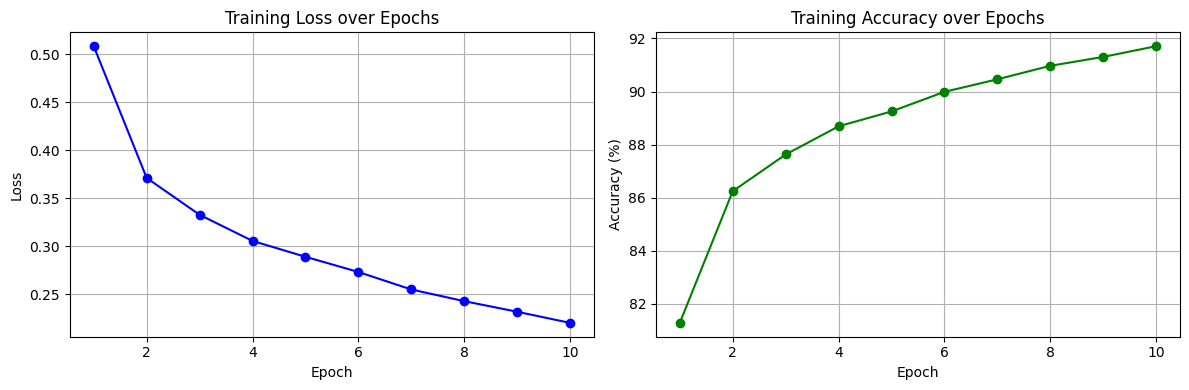

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot training loss
ax1.plot(range(1, num_epochs+1), train_losses, 'b-', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss over Epochs')
ax1.grid(True)

# Plot training accuracy
ax2.plot(range(1, num_epochs+1), train_accuracies, 'g-', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy over Epochs')
ax2.grid(True)

plt.tight_layout()
plt.show()